In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 6** — Cake Recipe Optimisation

Optimising five ingredient inputs to maximise a combined recipe score. Score is negative by design — goal is to get as close to zero as possible.

- **Optimisation Goal:** Maximise (closer to 0 = better)
- **Input:** 5D
- **All-time best:** -0.128 at [0.593, 0.387, 0.658, 0.780, 0.074] (Week 5)

Loading the cumulative dataset and appending the Week 7 result.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 6
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_outputs.npy')

# New data for Week 9 (Function 6)
X_w8_new_point = np.array([0.497821, 0.331178, 0.638314, 0.767495, 0.010657], dtype=np.float64)
Y_w8_new_point = np.array([-0.2508562556617444], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w8_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

Y_all = np.append(Y, Y_w8_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_6/initial_outputs.npy', Y_updated)

# Print arrays
print("Updated Inputs (X) - Function 6: ", X_unique)
print("Updated Outputs (Y) - Function 6: ", Y_updated)

Updated Inputs (X) - Function 6:  [[2.17353077e-02 4.28084240e-01 8.35939437e-01 4.89488659e-01
  5.11081735e-01]
 [1.25720155e-01 8.62724692e-01 2.85443322e-02 2.46605272e-01
  7.51206241e-01]
 [1.26678917e-01 2.91470301e-01 6.45284767e-02 6.80514603e-01
  8.92819191e-01]
 [1.45110786e-01 8.96684598e-01 8.96322235e-01 7.26271537e-01
  2.36271991e-01]
 [2.42384347e-01 8.44099972e-01 5.77809099e-01 6.79021284e-01
  5.01952888e-01]
 [2.58905574e-01 7.93677708e-01 6.42113905e-01 1.96673464e-01
  5.93103177e-01]
 [4.32165933e-01 7.15617813e-01 3.41819103e-01 7.04999881e-01
  6.14961845e-01]
 [4.39344264e-01 6.98923833e-01 4.26820222e-01 1.09476085e-01
  8.77888468e-01]
 [4.41233000e-01 9.98122000e-01 1.24500000e-03 5.56711000e-01
  3.21098000e-01]
 [4.61344000e-01 3.23423000e-01 8.03851000e-01 9.69268000e-01
  2.51090000e-02]
 [4.87084000e-01 1.49390000e-02 9.99330000e-01 9.73696000e-01
  9.98860000e-02]
 [4.97821000e-01 3.31178000e-01 6.38314000e-01 7.67495000e-01
  1.06570000e-02]
 [5.07

## **Output Analysis**

- **Comparison**: Week 8 returned -0.251 at [0.498, 0.331, 0.638, 0.767, 0.011]. 
    - This is an improvement over Week 7 (-0.532) but remains significantly worse than my Week 5 all-time best of -0.128 at [0.593, 0.387, 0.658, 0.780, 0.074].

- **Real-World Implications**: In a 5-ingredient recipe, the balance is delicate. 
    - Our 5th variable ($x_5$) has collapsed toward zero (0.011), likely making the mixture too dry and causing the score to drop.
    
- **Model Clues**: Looking at the history, every time $x_5$ drops below 0.05, the performance tanks. 
    - The GP is currently struggling to realize that $x_5$ has a hard floor requirement for a successful recipe. 
    - It is exploring the boundary (zero) because it hasn't gathered enough negative data there to fear it yet.

- **Key Change for w9**: We are implementing a Constraint-Aware search. 
    - I will manually restrict our candidate generator to ignore any recipes where $x_5 < 0.06$. 
        - This forces the model to stay in the "moist" zone where our Week 5 success occurred.

## **Bayesian Optimisation**
- **Model**: Gaussian Process Regressor with Matern (nu=2.5) + WhiteKernel and Yeo-Johnson transformation.

- **Reasoning**: 5D spaces are prone to the curse of dimensionality. 
    - The Matern kernel helps maintain local structure, while the Yeo-Johnson transformation helps the model navigate the negative-space scoring (closer to 0 is better).

- **Changes for Week 9**: The model remains the same, but I am shifting the focus of the data it prioritizes. 
    - I am centering our search cloud on the Week 5 best rather than the most recent Week 8 result.

- **Intended Impact**: To pull the search out of the low-milk trap and re-examine the high-performing neighborhood of our -0.128 record.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

# 3. Fit Model
kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- **Strategy**: Expected Improvement (EI) with a Physical Constraint Floor.
    - **Reasoning**: Since I know the recipe fails when $x_5$ is too low, I shouldn't even ask the model to evaluate those points. 
        - By clipping the search space, I ensure the query is physically viable.

- **Key Changes**: I am using a focused grid centered on the Week 5 best [0.593, 0.387, 0.658, 0.780, 0.074] and clipping $x_5$ to a minimum of 0.06.

In [5]:
def expected_improvement(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w5_best = np.array([0.593, 0.387, 0.658, 0.780, 0.074])
x_grid = np.random.normal(loc=w5_best, scale=0.03, size=(10000, 5))

x_grid[:, 4] = np.maximum(x_grid[:, 4], 0.06)
x_grid = np.clip(x_grid, 0, 1)

# 6. Selection
y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max)
next_query = x_grid[np.argmax(ei_values)]

print(f"Next Query Point (F6): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}")

Next Query Point (F6): 0.500522-0.344002-0.612748-0.734912-0.090373


## **Visualisation**

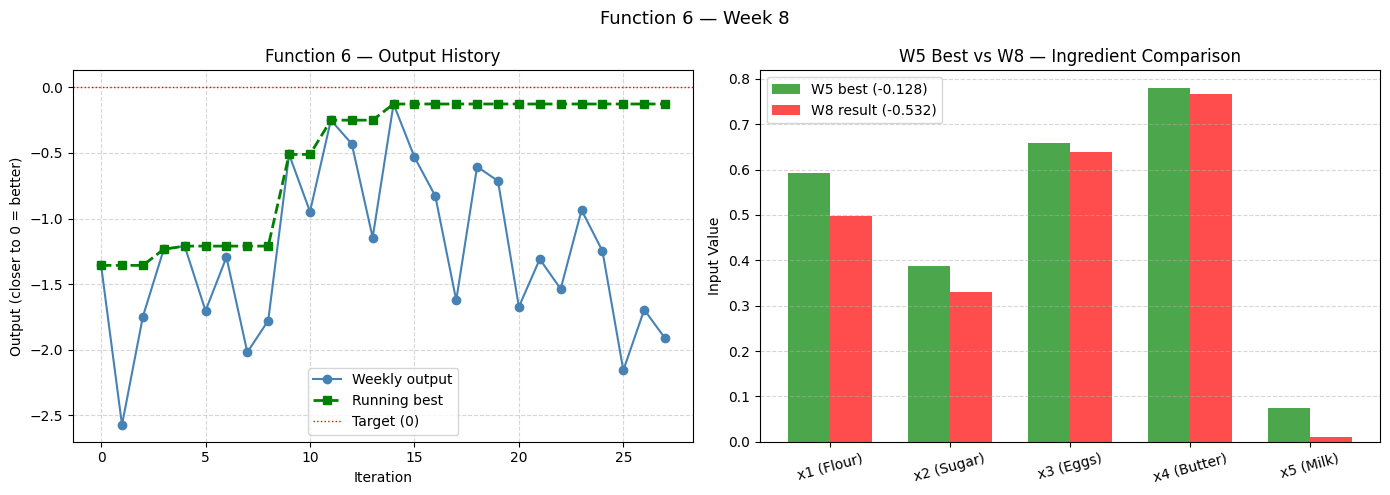

In [6]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].axhline(0, color='red', linestyle=':', linewidth=1, label='Target (0)')
axes[0].set_title('Function 6 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output (closer to 0 = better)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Show the W5 best ingredient profile vs W7 for comparison
ingredient_labels = ['x1 (Flour)', 'x2 (Sugar)', 'x3 (Eggs)', 'x4 (Butter)', 'x5 (Milk)']
x = np.arange(len(ingredient_labels))
width = 0.35
axes[1].bar(x - width/2, w5_best, width, label='W5 best (-0.128)', color='green', alpha=0.7)
axes[1].bar(x + width/2, X_w8_new_point, width, label='W8 result (-0.532)', color='red', alpha=0.7)
axes[1].set_title('W5 Best vs W8 — Ingredient Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ingredient_labels, rotation=15)
axes[1].set_ylabel('Input Value')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 6 — Week 8', fontsize=13)
plt.tight_layout()
plt.show()